In [8]:
import sys, os, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data_loader import load_processed, NUM_CLASSES, DATA_PROC, EMOTION_LABELS
from preprocess import (
    full_preprocess_pipeline, load_preprocessed_as_dataset,
    normalize_images, add_channel_dim, one_hot_encode, BATCH_SIZE
)
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {[g.name for g in gpus] or "None (CPU mode)"}')
print('Setup OK')

TensorFlow: 2.15.0
GPUs: ['/physical_device:GPU:0']
Setup OK


In [9]:
# Cell 2 — Load raw arrays from Notebook 01
train_images_raw, train_labels_raw = load_processed('train_raw')
val_images_raw,   val_labels_raw   = load_processed('val_raw')
test_images_raw,  test_labels_raw  = load_processed('test_raw')
print(f'\nRaw shapes:')
print(f'  train: {train_images_raw.shape}  labels: {train_labels_raw.shape}')
print(f'  val  : {val_images_raw.shape}')
print(f'  test : {test_images_raw.shape}')

Loaded train_raw: (25838, 48, 48), (25838,)
Loaded val_raw: (2871, 48, 48), (2871,)
Loaded test_raw: (7178, 48, 48), (7178,)

Raw shapes:
  train: (25838, 48, 48)  labels: (25838,)
  val  : (2871, 48, 48)
  test : (7178, 48, 48)


In [10]:
# Cell 3 — Run preprocessing pipeline (vectorized — no slow loops)
start = time.time()
train_ds, train_images, train_labels = full_preprocess_pipeline(
    train_images_raw, train_labels_raw, 'train', augment=True, save=True
)
val_ds, val_images, val_labels = full_preprocess_pipeline(
    val_images_raw, val_labels_raw, 'val', augment=False, save=True
)
test_ds, test_images, test_labels = full_preprocess_pipeline(
    test_images_raw, test_labels_raw, 'test', augment=False, save=True
)
print(f'\nTotal preprocessing time: {time.time()-start:.1f}s')
print('   (Vectorized NumPy — no Python loops)')


Preprocessing [train]  (25838 samples)
   images: (25838, 48, 48, 1) dtype=float32 min=0.000 max=1.000
   labels: (25838, 7) (one-hot, 7 classes)
Saved to data/processed/train_*.npy
Dataset ready  (augment=True, batch_size=64)

Preprocessing [val]  (2871 samples)
   images: (2871, 48, 48, 1) dtype=float32 min=0.000 max=1.000
   labels: (2871, 7) (one-hot, 7 classes)
Saved to data/processed/val_*.npy
Dataset ready  (augment=False, batch_size=64)

Preprocessing [test]  (7178 samples)
   images: (7178, 48, 48, 1) dtype=float32 min=0.000 max=1.000
   labels: (7178, 7) (one-hot, 7 classes)
Saved to data/processed/test_*.npy
Dataset ready  (augment=False, batch_size=64)

Total preprocessing time: 1.3s
   (Vectorized NumPy — no Python loops)


In [11]:
# Cell 4 — Verify shapes after preprocessing
print('After preprocessing:')
print(f'  train_images : {train_images.shape}  dtype={train_images.dtype}  max={train_images.max():.2f}')
print(f'  train_labels : {train_labels.shape}  (one-hot, {NUM_CLASSES} classes)')
print(f'  val_images   : {val_images.shape}')
print(f'  test_images  : {test_images.shape}')
print('\nAll shapes correct for CNN input (N, 48, 48, 1)')

After preprocessing:
  train_images : (25838, 48, 48, 1)  dtype=float32  max=1.00
  train_labels : (25838, 7)  (one-hot, 7 classes)
  val_images   : (2871, 48, 48, 1)
  test_images  : (7178, 48, 48, 1)

All shapes correct for CNN input (N, 48, 48, 1)


In [12]:
# Cell 5 — Inspect one batch from tf.data pipeline
for batch_images, batch_labels in train_ds.take(1):
    print(f'Batch images : {batch_images.shape}')
    print(f'Batch labels : {batch_labels.shape}')
    print(f'Pixel range  : [{batch_images.numpy().min():.3f}, {batch_images.numpy().max():.3f}]')
    print(f'Label sample : {batch_labels.numpy()[0]}')
    print(f'  → class {batch_labels.numpy()[0].argmax()} = {EMOTION_LABELS[int(batch_labels.numpy()[0].argmax())]}')

Batch images : (64, 48, 48, 1)
Batch labels : (64, 7)
Pixel range  : [0.000, 1.000]
Label sample : [0. 0. 0. 0. 0. 0. 1.]
  → class 6 = Neutral


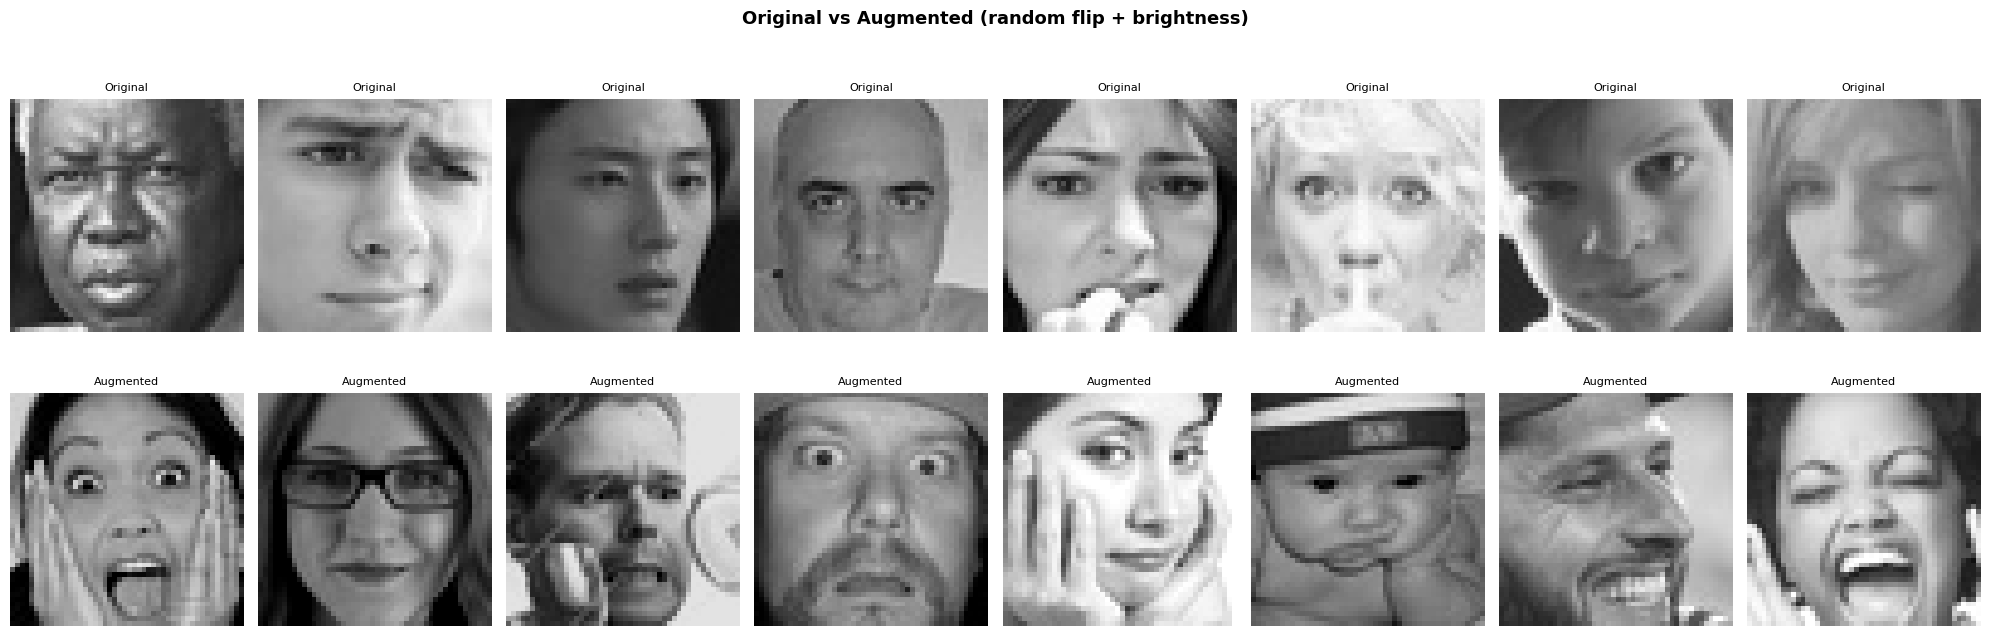

In [13]:
# Cell 6 — Visualize augmentation effect
fig, axes = plt.subplots(2, 8, figsize=(20, 7))
fig.suptitle('Original vs Augmented (random flip + brightness)',
             fontsize=13, fontweight='bold')
orig_imgs = train_images[:8, :, :, 0]
for i in range(8):
    axes[0, i].imshow(orig_imgs[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Original', fontsize=8)
    axes[0, i].axis('off')
# Augmented
for batch_imgs, _ in train_ds.take(1):
    aug_imgs = batch_imgs.numpy()[:8, :, :, 0]
for i in range(8):
    axes[1, i].imshow(aug_imgs[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Augmented', fontsize=8)
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'outputs' / 'augmentation_preview.png'), dpi=120)
plt.show()

In [14]:
# Cell 7 — Summary of saved files
print('Preprocessed files in data/processed/:')
total_mb = 0
for f in sorted(DATA_PROC.glob('*.npy')):
    mb = f.stat().st_size / 1024 / 1024
    total_mb += mb
    print(f'  {f.name:<35} {mb:6.1f} MB')
print(f'  {"TOTAL":<35} {total_mb:6.1f} MB')

Preprocessed files in data/processed/:
  test_images_proc.npy                  63.1 MB
  test_labels_ohe.npy                    0.2 MB
  test_raw_images.npy                   63.1 MB
  test_raw_labels.npy                    0.0 MB
  train_images_proc.npy                227.1 MB
  train_labels_ohe.npy                   0.7 MB
  train_raw_images.npy                 227.1 MB
  train_raw_labels.npy                   0.1 MB
  val_images_proc.npy                   25.2 MB
  val_labels_ohe.npy                     0.1 MB
  val_raw_images.npy                    25.2 MB
  val_raw_labels.npy                     0.0 MB
  TOTAL                                631.9 MB
